 # Cow Detection + Behavior Classification Pipeline



 **Objective**: Combine YOLO detection with ViT classification for end-to-end cow behavior analysis on raw video frames.



 **Dataset**: 25K labeled cow crops across 5 behaviors (drinking, foraging, lying, rumination, standing)



 **Models**:

 - YOLO cow detector (trained on bounding box annotations)

 - ViT behavior classifier (92.6% accuracy on crops)



 **Pipeline**: Raw Frame → Detection → Crop Extraction → Classification → Annotated Results

In [1]:
# Core Python & data handling
import cv2
import numpy as np
from pathlib import Path
import subprocess

# ML libraries  
import torch
import torch.nn.functional as F
from ultralytics import YOLO
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from IPython.display import Video, display

# Set device and seed
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", torch.cuda.get_device_name())
torch.manual_seed(42)


Using: NVIDIA GeForce RTX 4080


In [2]:
# Configuration
YOLO_MODEL_PATH = "runs/detect/train3/weights/best.pt"
VIT_MODEL_PATH = "models/cow-behavior-vit"
DETECTION_CONF = 0.25
IMG_SIZE = 640
SEED = 42


In [3]:
# Load models with validation
assert Path(YOLO_MODEL_PATH).exists(), f"YOLO model not found: {YOLO_MODEL_PATH}"
assert Path(VIT_MODEL_PATH).exists(), f"ViT model not found: {VIT_MODEL_PATH}"

detector = YOLO(YOLO_MODEL_PATH)
processor = AutoImageProcessor.from_pretrained(VIT_MODEL_PATH, use_fast=True)
classifier = AutoModelForImageClassification.from_pretrained(VIT_MODEL_PATH).to(device)
classifier.eval()

# Get class mappings
id2label = classifier.config.id2label
class_names = list(id2label.values())
print(f"Loaded models. Classes: {class_names}")

# Quick validation test
test_crop = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    _ = classifier(test_crop)
print("✓ Pipeline ready")


Loaded models. Classes: ['drinking water', 'foraging', 'lying down', 'rumination', 'stand']
✓ Pipeline ready


In [4]:
# Core pipeline functions with BotSort tracking
def detect_and_track(source, persist=True):
    """Run YOLO detection with BotSort tracking"""
    results = detector.track(source=source, tracker='botsort.yaml',
                            conf=DETECTION_CONF, persist=persist, verbose=False)[0]
    if len(results.boxes) == 0:
        return [], []

    boxes = results.boxes.xyxy.cpu().numpy().astype(int)
    track_ids = results.boxes.id.cpu().numpy().astype(int) if results.boxes.id is not None else None
    return boxes, track_ids

def classify_behavior(crop):
    # Classify cow behavior from image crop
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    inputs = processor(Image.fromarray(crop_rgb), return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        logits = classifier(**inputs).logits
        probs = F.softmax(logits, dim=-1)
    
    pred_id = logits.argmax().item()
    return {"class": id2label[pred_id], "conf": probs[0][pred_id].item()}

def process_image(image_path, use_tracking=True):
    """Complete pipeline: detect + track + classify"""
    image = cv2.imread(str(image_path))
    boxes, track_ids = detect_and_track(image_path, persist=use_tracking)

    results = []
    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        crop = image[y1:y2, x1:x2]
        behavior = classify_behavior(crop)
        results.append({
            "bbox": box.tolist(),
            "track_id": int(track_ids[idx]) if track_ids is not None else None,
            "behavior": behavior["class"],
            "conf": behavior["conf"]
        })

    return results

def process_video(video_path, output_path, max_frames=30):
    """Process video with BotSort tracking + behavior classification + timeline analysis"""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {"frames": 0, "detections": 0, "unique_tracks": 0}

    fps, width, height = (int(cap.get(p)) for p in [cv2.CAP_PROP_FPS, cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT])

    # Write to temporary file first, then convert with ffmpeg for compatibility
    temp_output = str(output_path).replace('.mp4', '_temp.avi')
    writer = cv2.VideoWriter(temp_output, cv2.VideoWriter_fourcc(*'MJPG'), fps, (width, height))

    stats = {"frames": 0, "detections": 0, "unique_tracks": set(), "track_timelines": {}, "fps": fps}

    try:
        while cap.isOpened() and stats["frames"] < max_frames:
            ret, frame = cap.read()
            if not ret:
                break

            boxes, track_ids = detect_and_track(frame, persist=True)

            for idx, box in enumerate(boxes):
                x1, y1, x2, y2 = box
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0:
                    continue

                track_id = int(track_ids[idx]) if track_ids is not None else None
                behavior = classify_behavior(crop)

                # Track timeline: record behavior per frame
                if track_id is not None:
                    stats["unique_tracks"].add(track_id)
                    stats["track_timelines"].setdefault(track_id, []).append(behavior["class"])
                    color = tuple(int(c) for c in np.random.RandomState(track_id).randint(100, 255, 3))
                else:
                    color = (0, 255, 0)

                # Draw annotations
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                label = f"ID:{track_id} | {behavior['class']} ({behavior['conf']:.2f})" if track_id else f"{behavior['class']}"
                cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

            writer.write(frame)
            stats["detections"] += len(boxes)
            stats["frames"] += 1

        cap.release()
        writer.release()

        # Convert temp AVI to playable MP4 using ffmpeg
        if Path(temp_output).exists():
            convert_cmd = [
                'ffmpeg', '-y', '-i', temp_output,
                '-c:v', 'libx264', '-preset', 'fast',
                '-crf', '23', '-pix_fmt', 'yuv420p',
                str(output_path)
            ]
            subprocess.run(convert_cmd, capture_output=True, check=False)
            Path(temp_output).unlink()  # Delete temp file

        # Compute behavior durations (using actual video FPS for accurate timing)
        from collections import Counter
        stats["unique_tracks"] = len(stats["unique_tracks"])
        stats["behavior_durations"] = {}

        for tid, timeline in stats["track_timelines"].items():
            behavior_counts = Counter(timeline)
            total_frames = len(timeline)
            stats["behavior_durations"][tid] = {
                behavior: {
                    "frames": count,
                    "seconds": round(count / fps, 1),  # Accurate timing using video FPS
                    "percent": round(100 * count / total_frames, 1)
                }
                for behavior, count in behavior_counts.items()
            }

        print(f"✓ Saved: {output_path}")
        return stats

    except Exception as e:
        print(f"Error: {e}")
        cap.release()
        writer.release()
        return stats


In [5]:
# Visualization with BotSort tracking
def show_results(image_path, results=None, show_tracks=True):
    """Display detection + tracking results with color-coded track IDs"""
    image = cv2.imread(str(image_path))
    if results is None:
        results = process_image(image_path, use_tracking=show_tracks)

    for result in results:
        x1, y1, x2, y2 = result["bbox"]
        track_id = result.get("track_id")
        behavior, conf = result["behavior"], result["conf"]

        # Color by track ID
        color = tuple(int(c) for c in np.random.RandomState(track_id).randint(100, 255, 3)) if track_id else (0, 255, 0)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        label = f"ID:{track_id} | {behavior} ({conf:.2f})" if track_id and show_tracks else f"{behavior} ({conf:.2f})"
        cv2.putText(image, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    title = f"Tracked {len(results)} cows" if show_tracks else f"Detected {len(results)} cows"
    plt.title(title)
    plt.show()

    return results


 ## Demo: Detection Only



 Test detection + classification without tracking:

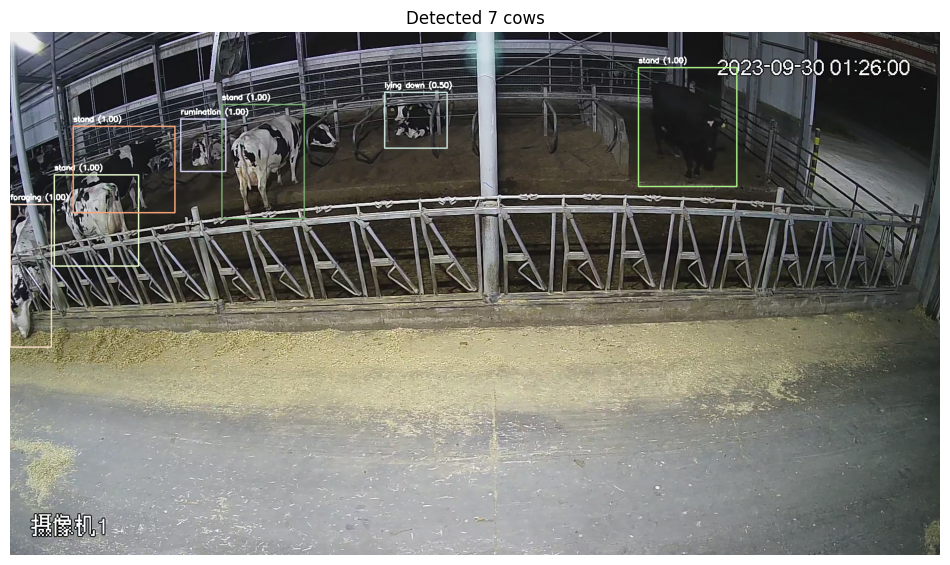

85_00007.jpg: 7 cows
  1. stand (0.998)
  2. stand (0.998)
  3. stand (0.999)
  4. lying down (0.502)
  5. foraging (0.998)
  6. rumination (0.998)
  7. stand (0.997)



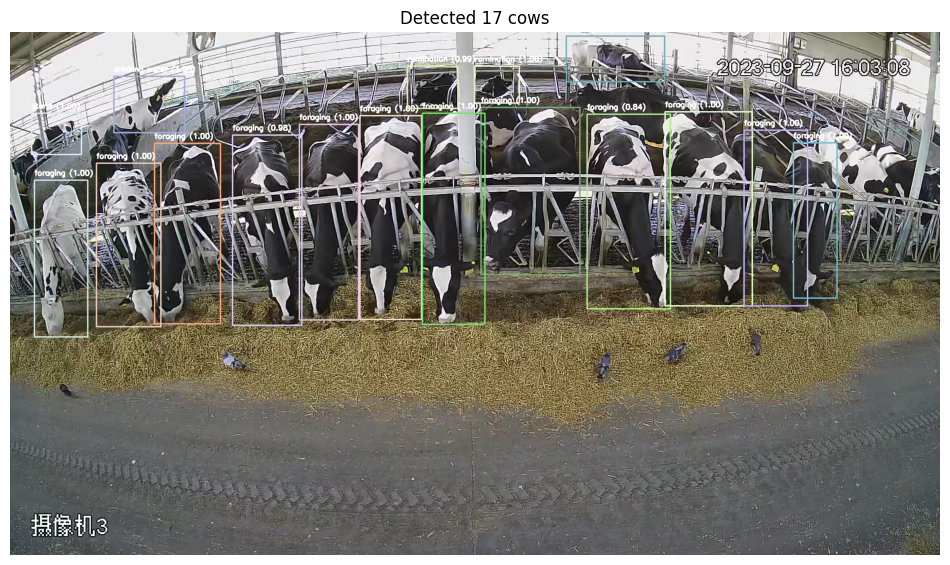

224_00005.jpg: 17 cows
  1. foraging (0.845)
  2. foraging (0.999)
  3. foraging (0.998)
  4. foraging (0.998)
  5. foraging (0.998)
  6. foraging (0.984)
  7. foraging (0.998)
  8. foraging (0.998)
  9. foraging (0.998)
  10. foraging (0.998)
  11. foraging (0.998)
  12. rumination (0.994)
  13. stand (0.999)
  14. foraging (0.998)
  15. stand (0.999)
  16. drinking water (0.995)
  17. rumination (0.997)



In [6]:
# Test on validation images (no tracking)
val_dir = Path("workdir/yolo_cow_oneclass/images/val")
if val_dir.exists():
    test_images = list(val_dir.glob("*.jpg"))[:2]
    if test_images:
        for img_path in test_images:
            results = show_results(str(img_path), show_tracks=False)
            print(f"{img_path.name}: {len(results)} cows")
            for i, r in enumerate(results, 1):
                print(f"  {i}. {r['behavior']} ({r['conf']:.3f})")
            print()
else:
    print(f"Directory not found: {val_dir}")


 ## Demo: BotSort Tracking



 Test with BotSort tracking to assign consistent IDs:

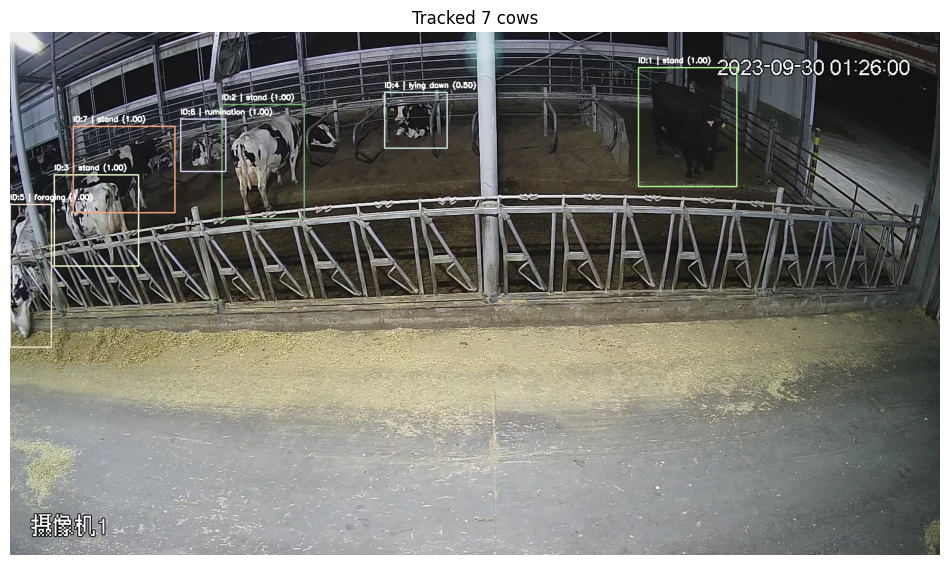

85_00007.jpg: 7 cows tracked
  Track 1: stand (0.998)
  Track 2: stand (0.998)
  Track 3: stand (0.999)
  Track 4: lying down (0.502)
  Track 5: foraging (0.998)
  Track 6: rumination (0.998)
  Track 7: stand (0.997)



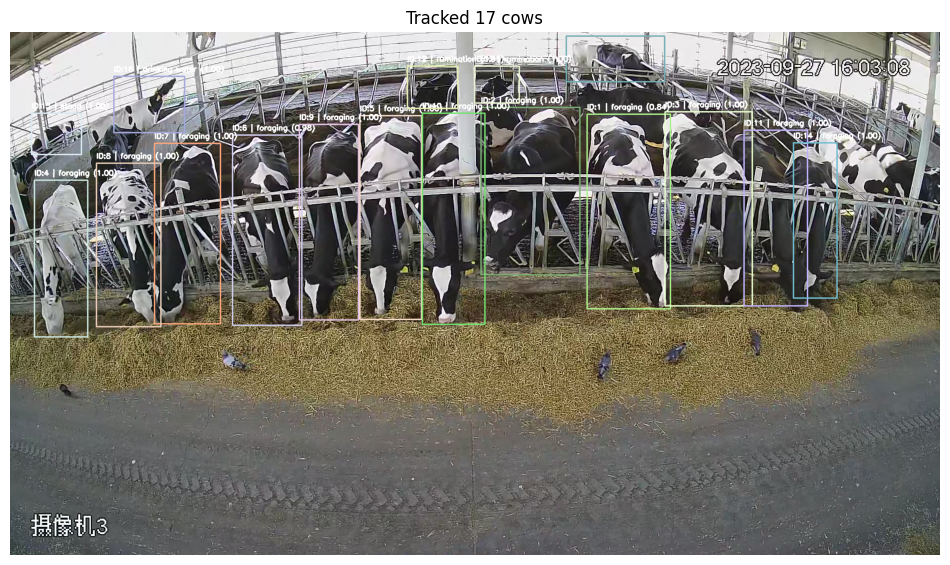

224_00005.jpg: 17 cows tracked
  Track 1: foraging (0.845)
  Track 2: foraging (0.999)
  Track 3: foraging (0.998)
  Track 4: foraging (0.998)
  Track 5: foraging (0.998)
  Track 6: foraging (0.984)
  Track 7: foraging (0.998)
  Track 8: foraging (0.998)
  Track 9: foraging (0.998)
  Track 10: foraging (0.998)
  Track 11: foraging (0.998)
  Track 12: rumination (0.994)
  Track 13: stand (0.999)
  Track 14: foraging (0.998)
  Track 15: stand (0.999)
  Track 16: drinking water (0.995)
  Track 17: rumination (0.997)



In [7]:
# Test with BotSort tracking
if val_dir.exists():
    test_images = list(val_dir.glob("*.jpg"))[:2]
    if test_images:
        for img_path in test_images:
            results = show_results(str(img_path), show_tracks=True)
            print(f"{img_path.name}: {len(results)} cows tracked")
            for r in results:
                tid = r.get('track_id', 'N/A')
                print(f"  Track {tid}: {r['behavior']} ({r['conf']:.3f})")
            print()
else:
    print(f"No validation images. Try: show_results('path/to/image.jpg')")


 ## Video Processing with BotSort Tracking



 Process video with persistent tracking across frames:

In [8]:
import random
import os
from pathlib import Path
from IPython.display import Video, display

# Assume process_video is already defined/imported

video_dir = Path("data/videos/videos")

if video_dir.exists():
    video_files = list(video_dir.glob("*.mp4"))
    if video_files:
        # Pick 5 random videos (or fewer if not enough available)
        selected_videos = random.sample(video_files, min(5, len(video_files)))

        for idx, random_video in enumerate(selected_videos, 1):
            print(f"\n{'='*40}\n▶ Processing video {idx}/{len(selected_videos)}: {random_video.name}")

            output_dir = Path("output_videos")
            output_dir.mkdir(exist_ok=True)
            output_path = output_dir / f"tracked_{random_video.stem}.mp4"

            stats = process_video(str(random_video), str(output_path), max_frames=50)

            print(f"\n📊 Summary:")
            print(f"  Frames: {stats['frames']} ({stats['frames']/stats['fps']:.1f}s @ {stats['fps']} fps)")
            print(f"  Detections: {stats['detections']}")
            print(f"  Unique cows tracked: {stats['unique_tracks']}")

            print(f"\n🐄 Behavior Timeline per Cow:")
            for tid in sorted(stats.get('behavior_durations', {}).keys()):
                durations = stats['behavior_durations'][tid]
                total_time = sum(d['seconds'] for d in durations.values())
                print(f"\n  Track {tid} (tracked for {total_time:.1f}s):")

                # Sort behaviors by duration descending
                for behavior, info in sorted(durations.items(), key=lambda x: x[1]['seconds'], reverse=True):
                    print(f"    • {behavior:15s}: {info['seconds']:4.1f}s ({info['percent']:4.1f}%)")

            if output_path.exists():
                print(f"\n🎬 Annotated video:")
                display(Video(str(output_path), width=640, height=480))

    else:
        print(f"No .mp4 videos found in {video_dir}")
else:
    print(f"Video directory does not exist: {video_dir}")



▶ Processing video 1/5: 199.mp4
✓ Saved: output_videos/tracked_199.mp4

📊 Summary:
  Frames: 50 (2.0s @ 25 fps)
  Detections: 300
  Unique cows tracked: 6

🐄 Behavior Timeline per Cow:

  Track 1 (tracked for 2.0s):
    • foraging       :  2.0s (100.0%)

  Track 2 (tracked for 2.0s):
    • lying down     :  1.2s (62.0%)
    • rumination     :  0.8s (38.0%)

  Track 3 (tracked for 2.0s):
    • rumination     :  1.3s (66.0%)
    • lying down     :  0.7s (34.0%)

  Track 4 (tracked for 2.0s):
    • rumination     :  1.8s (90.0%)
    • lying down     :  0.2s (10.0%)

  Track 5 (tracked for 2.0s):
    • drinking water :  1.1s (56.0%)
    • rumination     :  0.9s (44.0%)

  Track 6 (tracked for 2.0s):
    • rumination     :  1.1s (56.0%)
    • drinking water :  0.8s (40.0%)
    • stand          :  0.1s ( 4.0%)

🎬 Annotated video:



▶ Processing video 2/5: 280.mp4
✓ Saved: output_videos/tracked_280.mp4

📊 Summary:
  Frames: 50 (2.0s @ 25 fps)
  Detections: 380
  Unique cows tracked: 8

🐄 Behavior Timeline per Cow:

  Track 1 (tracked for 2.0s):
    • foraging       :  2.0s (100.0%)

  Track 2 (tracked for 2.0s):
    • foraging       :  2.0s (100.0%)

  Track 3 (tracked for 2.0s):
    • foraging       :  1.0s (50.0%)
    • rumination     :  0.7s (36.0%)
    • lying down     :  0.3s (14.0%)

  Track 4 (tracked for 2.0s):
    • foraging       :  1.0s (50.0%)
    • rumination     :  0.9s (44.0%)
    • lying down     :  0.1s ( 6.0%)

  Track 5 (tracked for 2.0s):
    • rumination     :  1.9s (96.0%)
    • lying down     :  0.1s ( 4.0%)

  Track 6 (tracked for 2.0s):
    • stand          :  2.0s (100.0%)

  Track 7 (tracked for 2.0s):
    • stand          :  2.0s (100.0%)

  Track 8 (tracked for 1.2s):
    • foraging       :  1.0s (83.3%)
    • stand          :  0.2s (16.7%)

🎬 Annotated video:



▶ Processing video 3/5: 317.mp4
✓ Saved: output_videos/tracked_317.mp4

📊 Summary:
  Frames: 50 (2.0s @ 25 fps)
  Detections: 493
  Unique cows tracked: 10

🐄 Behavior Timeline per Cow:

  Track 1 (tracked for 2.0s):
    • rumination     :  2.0s (100.0%)

  Track 2 (tracked for 2.0s):
    • rumination     :  2.0s (100.0%)

  Track 3 (tracked for 2.0s):
    • rumination     :  1.4s (72.0%)
    • foraging       :  0.6s (28.0%)

  Track 4 (tracked for 2.0s):
    • foraging       :  0.8s (38.0%)
    • rumination     :  0.7s (36.0%)
    • stand          :  0.4s (22.0%)
    • drinking water :  0.1s ( 4.0%)

  Track 5 (tracked for 2.0s):
    • stand          :  1.2s (60.0%)
    • foraging       :  0.4s (22.0%)
    • drinking water :  0.3s (14.0%)
    • rumination     :  0.1s ( 4.0%)

  Track 6 (tracked for 2.0s):
    • foraging       :  1.8s (90.0%)
    • stand          :  0.2s ( 8.0%)
    • rumination     :  0.0s ( 2.0%)

  Track 7 (tracked for 2.0s):
    • stand          :  1.2s (58.0%)
  


▶ Processing video 4/5: 564.mp4
✓ Saved: output_videos/tracked_564.mp4

📊 Summary:
  Frames: 50 (2.0s @ 25 fps)
  Detections: 50
  Unique cows tracked: 1

🐄 Behavior Timeline per Cow:

  Track 1 (tracked for 2.0s):
    • stand          :  2.0s (100.0%)

🎬 Annotated video:



▶ Processing video 5/5: 495.mp4
✓ Saved: output_videos/tracked_495.mp4

📊 Summary:
  Frames: 50 (2.0s @ 25 fps)
  Detections: 746
  Unique cows tracked: 16

🐄 Behavior Timeline per Cow:

  Track 1 (tracked for 2.0s):
    • foraging       :  2.0s (100.0%)

  Track 2 (tracked for 2.0s):
    • foraging       :  2.0s (100.0%)

  Track 3 (tracked for 2.0s):
    • stand          :  2.0s (100.0%)

  Track 4 (tracked for 2.0s):
    • foraging       :  1.5s (76.0%)
    • stand          :  0.5s (24.0%)

  Track 5 (tracked for 2.0s):
    • stand          :  1.5s (76.0%)
    • foraging       :  0.5s (24.0%)

  Track 6 (tracked for 2.0s):
    • foraging       :  1.8s (92.0%)
    • stand          :  0.2s ( 8.0%)

  Track 7 (tracked for 2.0s):
    • stand          :  1.5s (76.0%)
    • rumination     :  0.3s (16.0%)
    • foraging       :  0.2s ( 8.0%)

  Track 8 (tracked for 2.0s):
    • rumination     :  1.6s (78.0%)
    • stand          :  0.3s (16.0%)
    • lying down     :  0.1s ( 6.0%)

  Trac